In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv("data/raw/customer_support_100_1.csv")

In [6]:
df.head()

,ticket_id,ticket,category,priority
0,1,I was charged twice for the same order.,Billing,High
1,2,My monthly subscription payment went through b...,Billing,Medium
2,3,Why was I charged €12.99 when my plan should c...,Billing,Medium
3,4,I do not recognise the charge on my bank state...,Billing,High
4,5,Can you tell me when my next subscription paym...,Billing,Low


In [7]:
# this will be the shape of the data that will be acessed
df.shape

(100, 4)

In [8]:
df.columns

Index(['ticket_id', 'ticket', 'category', 'priority'], dtype='str')

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   ticket_id  100 non-null    int64
 1   ticket     100 non-null    str  
 2   category   100 non-null    str  
 3   priority   100 non-null    str  
dtypes: int64(1), str(3)
memory usage: 9.3 KB


In [10]:
df.isnull().sum()

ticket_id    0
ticket       0
category     0
priority     0
dtype: int64

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df["category"].value_counts()

category
Billing      20
Technical    20
Account      20
Refund       20
Delivery     20
Name: count, dtype: int64

In [13]:
df = df.drop_duplicates()

In [14]:
df = df.dropna(subset=["ticket","category"])

In [15]:
df["ticket"] = df["ticket"].str.strip()

In [16]:
df.isnull().sum()

ticket_id    0
ticket       0
category     0
priority     0
dtype: int64

In [17]:
df["category"].value_counts()

category
Billing      20
Technical    20
Account      20
Refund       20
Delivery     20
Name: count, dtype: int64

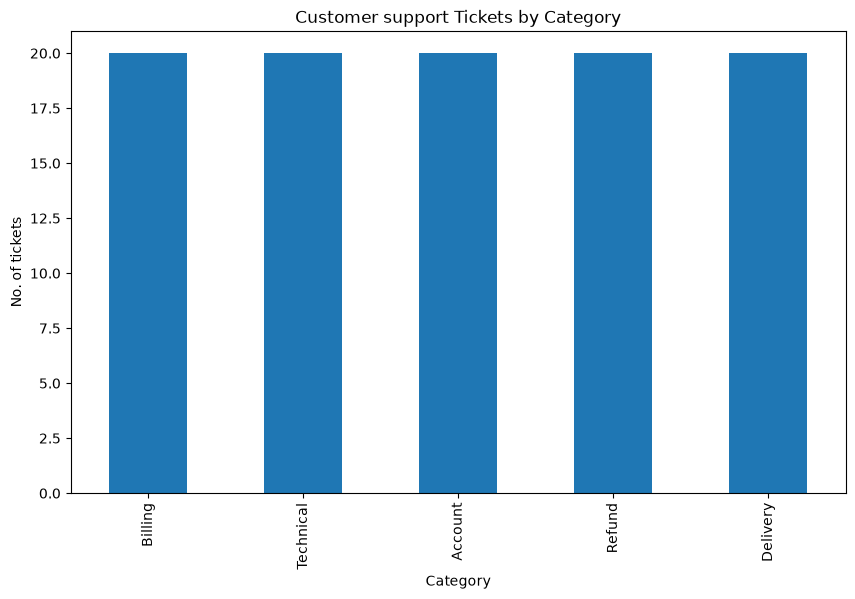

In [18]:
plt.figure(figsize=(10,6))

df["category"].value_counts().plot(kind="bar")

plt.title("Customer support Tickets by Category")
plt.xlabel("Category")
plt.ylabel("No. of tickets")
plt.show()

In [19]:
df.sample(10)[["ticket", "category"]]

,ticket,category
21,The website is loading very slowly today.,Technical
48,Someone changed my account email without my pe...,Account
55,I think somebody else has accessed my account.,Account
97,Can you arrange another delivery attempt?,Delivery
36,I am receiving the same notification several t...,Technical
77,I need to know whether this purchase is eligib...,Refund
99,The package arrived with the box badly damaged.,Delivery
22,I keep getting an error message when I upload ...,Technical
56,I never received the email asking me to verify...,Account
32,The dashboard takes several minutes to load.,Technical


In [20]:
df["query_length"] = df["ticket"].str.len()
df["query_length"].describe()

count    100.000000
mean      49.790000
std       10.797769
min       25.000000
25%       42.000000
50%       49.000000
75%       56.000000
max       81.000000
Name: query_length, dtype: float64

In [21]:
df.groupby("category")["query_length"].mean().sort_values()

category
Account      46.35
Technical    47.35
Delivery     48.50
Refund       52.60
Billing      54.15
Name: query_length, dtype: float64

In [22]:
# notice Billing and refund contain on average the longest queries
# This can become a problem for Customer support and very time consuming

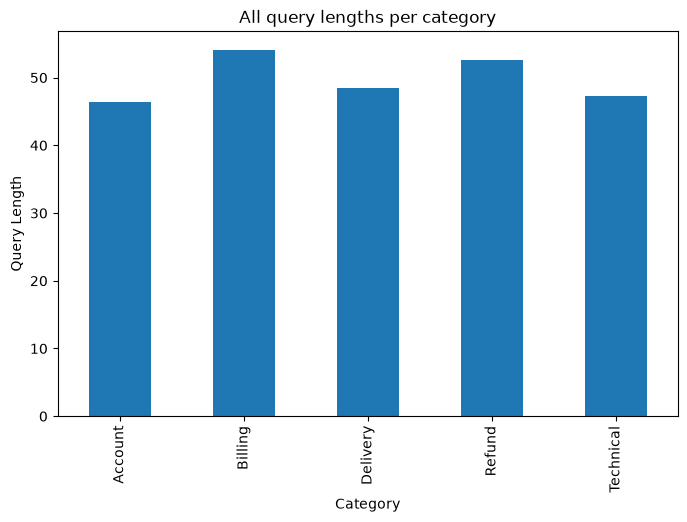

In [23]:
df.groupby("category")["query_length"].mean().plot(kind="bar", figsize=(8,5))

plt.title("All query lengths per category")
plt.xlabel("Category")
plt.ylabel("Query Length")
plt.show()   
